# PAIMANA Project Cost Prediction Model



## Cell 1 — Import Libraries

Core libraries, scikit-learn components, and XGBoost (imported defensively — if it
isn't installed, the notebook prints the install command and continues with Random
Forest only rather than crashing).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import json
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("XGBoost is available.")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is NOT installed. Install it with:\n  pip install xgboost\n"
          "Continuing with Random Forest only — the notebook remains fully runnable.")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

print("\nLibraries imported successfully.")


XGBoost is available.

Libraries imported successfully.


## Cell 2 — Load Dataset

Load `paimna_features.csv` and inspect its shape, structure, and missing-value profile.


In [2]:
DATA_PATH = "paimana_features.csv"
df = pd.read_csv(DATA_PATH)

print("=" * 50)
print("DATASET SHAPE:", df.shape)
print("=" * 50)

display(df.head())

print("\nALL COLUMNS:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 50)
print("DF.INFO()")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("MISSING VALUES SUMMARY")
print("=" * 50)
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_summary / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing_summary, "missing_pct": missing_pct})
display(missing_report[missing_report["missing_count"] > 0])

ORIGINAL_ROW_COUNT = len(df)


DATASET SHAPE: (9676, 23)


,report_month,project_code,project_name,agency,state,approval_date,start_date,original_doc,revised_doc,original_cost_cr,...,previous_progress,previous_expenditure,progress_change,expenditure_change,cost_utilization_pct,expenditure_progress_gap,project_age_days,days_to_original_completion,days_overdue,project_observation_number
0,2025-05-01,1,CIVIL AVIATION,38,"26,718.18 (27,878.25) {30,473.90}",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,1
1,2025-05-01,1,ANDAMAN AND NICOBAR ISLANDS,10,"2,956.02 (3,029.18) {3,010.04}",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,2
2,2026-05-01,1,Roads & Highways,1149,"1,067,985",1994-01-01,377-01-01,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,11808.0,NaN,0.0,3
3,2026-05-01,1,705728,MUMBAI-AHMEDABAD HIGH SPEED RAIL PROJECT- 508 KM,"108,000",108-01-01,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,700656.0,NaN,0.0,4
4,2026-05-01,1,Oil & Gas,93,"362,529",393-01-01,383-01-01,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,596561.0,NaN,0.0,5



ALL COLUMNS:
 1. report_month
 2. project_code
 3. project_name
 4. agency
 5. state
 6. approval_date
 7. start_date
 8. original_doc
 9. revised_doc
10. original_cost_cr
11. revised_cost_cr
12. cumulative_expenditure_cr
13. physical_progress_pct
14. previous_progress
15. previous_expenditure
16. progress_change
17. expenditure_change
18. cost_utilization_pct
19. expenditure_progress_gap
20. project_age_days
21. days_to_original_completion
22. days_overdue
23. project_observation_number

DF.INFO()
<class 'pandas.DataFrame'>
RangeIndex: 9676 entries, 0 to 9675
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   report_month                 9676 non-null   str    
 1   project_code                 9676 non-null   str    
 2   project_name                 9676 non-null   str    
 3   agency                       9172 non-null   str    
 4   state                        9264 non-null   s

,missing_count,missing_pct
start_date,9632,99.55
revised_cost_cr,9384,96.98
revised_doc,9151,94.57
progress_change,4279,44.22
previous_progress,3986,41.19
expenditure_change,3732,38.57
previous_expenditure,3623,37.44
physical_progress_pct,1407,14.54
expenditure_progress_gap,1407,14.54
project_age_days,1148,11.86


## Cell 3 — Clean Target Column

We define a **reusable numeric cleaning function** used throughout the notebook:



In [ ]:
def is_numeric_like(value):
    """True if `value` is a single valid number, optionally comma-formatted."""
    if pd.isna(value):
        return False
    s = str(value).strip()
    if s == "":
        return False
    pattern = r"^-?\d{1,3}(,\d{3})*(\.\d+)?$|^-?\d+(\.\d+)?$"
    return bool(re.match(pattern, s))


def is_financial_like(value):
    """True if the string contains multiple distinct numeric groups or bracket
    characters alongside digits — a signature of the corrupted rows in this dataset."""
    if pd.isna(value):
        return False
    s = str(value).strip()
    if s == "":
        return False
    numbers_found = re.findall(r"\d{1,3}(?:,\d{3})*(?:\.\d+)?|\d+(?:\.\d+)?", s)
    has_containers = bool(re.search(r"[\(\)\{\}\[\]]", s)) and bool(re.search(r"\d", s))
    return len(numbers_found) > 1 or has_containers


def clean_numeric_value(value):
    """Reusable numeric cleaner used on every numeric column in this notebook.
    - Single valid numbers (with or without commas) -> converted to float.
    - Multi-number / bracketed 'financial-looking' cells -> NaN (ambiguous).
    - Anything else that can't be safely parsed -> NaN.
    """
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    s = str(value).strip()
    if s == "":
        return np.nan
    if is_numeric_like(s):
        return float(s.replace(",", ""))
    if is_financial_like(s):
        return np.nan
    try:
        return float(s.replace(",", ""))
    except ValueError:
        return np.nan


def clean_numeric_series(series):
    return series.apply(clean_numeric_value)


TARGET = "cumulative_expenditure_cr"
if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' not found. Available columns: {list(df.columns)}")

before_valid = df[TARGET].notna().sum()
df[TARGET] = clean_numeric_series(df[TARGET])
after_valid = df[TARGET].notna().sum()

print(f"Valid target values before cleaning: {before_valid}")
print(f"Valid target values after cleaning:  {after_valid}")
print(f"Missing/invalid target values (to be dropped): {df[TARGET].isna().sum()}")

df = df.dropna(subset=[TARGET]).copy()
print(f"\nRows remaining after dropping missing/invalid target: {len(df)} "
      f"(dropped {ORIGINAL_ROW_COUNT - len(df)} rows)")


Valid target values before cleaning: 8676
Valid target values after cleaning:  8676
Missing/invalid target values (to be dropped): 1000

Rows remaining after dropping missing/invalid target: 8676 (dropped 1000 rows)


## Cell 4 — Clean Numeric Features

We identify which candidate numeric feature columns actually exist in this dataset,
then clean each one with the same `clean_numeric_series` function defined above,
reporting missing-value counts before and after.


In [4]:
candidate_numeric_cols = [
    "original_cost_cr", "revised_cost_cr", "physical_progress_pct", "previous_progress",
    "previous_expenditure", "progress_change", "expenditure_change", "cost_utilization_pct",
    "expenditure_progress_gap", "project_age_days", "days_to_original_completion", "days_overdue"
]
numeric_cols_present = [c for c in candidate_numeric_cols if c in df.columns]
print("Numeric feature columns found:", numeric_cols_present)

print("\n{:35s} {:>12s} {:>12s}".format("Column", "Missing Before", "Missing After"))
for col in numeric_cols_present:
    before = df[col].isna().sum()
    df[col] = clean_numeric_series(df[col])
    after = df[col].isna().sum()
    print(f"{col:35s} {before:>14d} {after:>13d}")


Numeric feature columns found: ['original_cost_cr', 'revised_cost_cr', 'physical_progress_pct', 'previous_progress', 'previous_expenditure', 'progress_change', 'expenditure_change', 'cost_utilization_pct', 'expenditure_progress_gap', 'project_age_days', 'days_to_original_completion', 'days_overdue']

Column                              Missing Before Missing After
original_cost_cr                                 0             0
revised_cost_cr                               8386          8386
physical_progress_pct                          407           407
previous_progress                             3082          3082
previous_expenditure                          2732          2732
progress_change                               3279          3279
expenditure_change                            2732          2732
cost_utilization_pct                             0             0
expenditure_progress_gap                       407           407
project_age_days                               4

## Cell 5 — Clean Categorical Features

`agency` and `state` (whichever exist) may contain numeric-only or financial-looking
junk values, per the known corruption pattern. We reuse `is_numeric_like` and
`is_financial_like` from Cell 3 to detect and null out these corrupted entries while
leaving genuine category text untouched.


In [5]:
candidate_categorical_cols = ["agency", "state"]
categorical_cols_present = [c for c in candidate_categorical_cols if c in df.columns]
print("Categorical feature columns found:", categorical_cols_present)


def clean_categorical_series(series):
    """Null out numeric-like or financial-like corrupted values; keep genuine text."""
    corrupted_mask = series.apply(lambda v: is_numeric_like(v) or is_financial_like(v))
    n_corrupted = int(corrupted_mask.sum())
    cleaned = series.copy()
    cleaned[corrupted_mask] = np.nan
    return cleaned, n_corrupted


print()
for col in categorical_cols_present:
    df[col], n_removed = clean_categorical_series(df[col])
    print(f"{col}: {n_removed} suspicious (numeric/financial-looking) value(s) removed -> NaN. "
          f"Remaining valid values: {df[col].notna().sum()}")


Categorical feature columns found: ['agency', 'state']

agency: 2244 suspicious (numeric/financial-looking) value(s) removed -> NaN. Remaining valid values: 5934
state: 0 suspicious (numeric/financial-looking) value(s) removed -> NaN. Remaining valid values: 8267


## Cell 6 — Date / Time Features

Date columns are parsed with `errors="coerce"` so invalid/unrealistic dates become
`NaT` instead of breaking the notebook. Raw dates aren't fed to the model directly —
instead we derive simple numeric time features (`report_year`, `report_month_number`,
`project_start_year`) that scikit-learn can actually use, and only when the source
column exists.


In [6]:
date_columns_to_parse = ["report_month", "approval_date", "start_date"]
for col in date_columns_to_parse:
    if col in df.columns:
        before_na = df[col].isna().sum()
        df[col] = pd.to_datetime(df[col], errors="coerce")
        after_na = df[col].isna().sum()
        print(f"{col}: parsed to datetime. NaT introduced by coercion: {after_na - before_na}")
    else:
        print(f"Column '{col}' not found — skipping.")

derived_time_features = []

if "report_month" in df.columns:
    df["report_year"] = df["report_month"].dt.year
    df["report_month_number"] = df["report_month"].dt.month
    derived_time_features += ["report_year", "report_month_number"]

if "start_date" in df.columns:
    df["project_start_year"] = df["start_date"].dt.year
    derived_time_features += ["project_start_year"]

print("\nDerived time features created:", derived_time_features)


report_month: parsed to datetime. NaT introduced by coercion: 0
approval_date: parsed to datetime. NaT introduced by coercion: 3841
start_date: parsed to datetime. NaT introduced by coercion: 0

Derived time features created: ['report_year', 'report_month_number', 'project_start_year']


## Cell 7 — Final Feature Selection

**Leakage exclusions:**
- `cumulative_expenditure_cr` — the target itself.
- `expenditure_change` — computed directly from the target
  (`cumulative_expenditure_cr - previous_expenditure`), so it would leak the answer.
- `cost_utilization_pct`, `expenditure_progress_gap` — excluded defensively, since
  these are very likely derived using the target (e.g. expenditure / cost), which
  would leak the answer just as directly.

**`previous_expenditure` is historical information available at prediction time and is
therefore treated as a valid predictive feature.**

**Identifier exclusions (baseline model):** `project_code`, `project_name` — unique
identifiers with no generalizable predictive signal, excluded from this baseline per
the brief unless there's a strong justification (there isn't one here).

Raw date columns are excluded in favor of the derived numeric time features from Cell 6.


In [7]:
LEAKAGE_COLUMNS = {
    TARGET, "expenditure_change", "cost_utilization_pct", "expenditure_progress_gap"
}
ID_COLUMNS = {"project_code", "project_name"}
RAW_DATE_COLUMNS = {"report_month", "approval_date", "start_date"}

candidate_features = (
    [c for c in numeric_cols_present if c not in LEAKAGE_COLUMNS]
    + derived_time_features
    + categorical_cols_present
)

selected_features = [
    c for c in candidate_features
    if c in df.columns and c not in LEAKAGE_COLUMNS
    and c not in ID_COLUMNS and c not in RAW_DATE_COLUMNS
]
# de-duplicate while preserving order
selected_features = list(dict.fromkeys(selected_features))

numeric_features = [c for c in selected_features if c in numeric_cols_present + derived_time_features]
categorical_features = [c for c in selected_features if c in categorical_cols_present]

X = df[selected_features].copy()
y = df[TARGET].copy()

print("Selected NUMERICAL features:", numeric_features)
print("Selected CATEGORICAL features:", categorical_features)
print(f"\nTotal input features before one-hot encoding: {len(selected_features)}")
print(f"Target column included in X? {'YES - ERROR!' if TARGET in X.columns else 'No (correct)'}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")


Selected NUMERICAL features: ['original_cost_cr', 'revised_cost_cr', 'physical_progress_pct', 'previous_progress', 'previous_expenditure', 'progress_change', 'project_age_days', 'days_to_original_completion', 'days_overdue', 'report_year', 'report_month_number', 'project_start_year']
Selected CATEGORICAL features: ['agency', 'state']

Total input features before one-hot encoding: 14
Target column included in X? No (correct)

X shape: (8676, 14)
y shape: (8676,)


## Cell 8 — Train / Test Split

80% train / 20% test, `random_state=42`. This is a **baseline random split**. Because
the dataset contains `report_month`, a future production version of this model should
use a **temporal split** (train on earlier months, test on the most recent months) to
more realistically simulate forecasting forward in time rather than mixing time periods.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("\nNote: baseline RANDOM split. A future production version should use a TEMPORAL "
      "split on 'report_month' (train on earlier months, test on later months).")


Training samples: 6940
Testing samples:  1736

Note: baseline RANDOM split. A future production version should use a TEMPORAL split on 'report_month' (train on earlier months, test on later months).


## Cell 9 — Preprocessing Pipeline

A single `ColumnTransformer` — median imputation for numeric features, most-frequent
imputation + one-hot encoding (`handle_unknown="ignore"`) for categorical features.
This exact `preprocessor` object is reused, unmodified, inside both the Random Forest
and the XGBoost pipelines, so both models see identically preprocessed data.


In [9]:
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline created:")
print(preprocessor)


Preprocessing pipeline created:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['original_cost_cr', 'revised_cost_cr',
                                  'physical_progress_pct', 'previous_progress',
                                  'previous_expenditure', 'progress_change',
                                  'project_age_days',
                                  'days_to_original_completion', 'days_overdue',
                                  'report_year', 'report_month_number',
                                  'project_start_year']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                

## Cell 10 — Baseline Model

A `DummyRegressor(strategy="mean")` establishes the floor every real model must beat.


In [10]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(X_train, y_train)
y_pred_dummy = dummy_model.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

print("BASELINE MODEL PERFORMANCE")
print("-" * 27)
print(f"MAE:      {mae_dummy:,.2f}")
print(f"RMSE:     {rmse_dummy:,.2f}")
print(f"R2 Score: {r2_dummy:.4f}")


BASELINE MODEL PERFORMANCE
---------------------------
MAE:      2,932.30
RMSE:     8,045.31
R2 Score: -0.0002


## Cell 11 — Random Forest Model

`preprocessor` + `RandomForestRegressor` in a single `Pipeline`, fit only on training data.


In [11]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300, max_depth=None, min_samples_split=5,
        min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1
    ))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("\nRANDOM FOREST PERFORMANCE")
print("-" * 27)
print(f"MAE:      {mae_rf:,.2f}")
print(f"RMSE:     {rmse_rf:,.2f}")
print(f"R2 Score: {r2_rf:.4f}")


Training Random Forest...

RANDOM FOREST PERFORMANCE
---------------------------
MAE:      184.77
RMSE:     914.72
R2 Score: 0.9871


## Cell 12 — XGBoost Model

The **same** `preprocessor` inside a fresh `Pipeline` with `XGBRegressor`, so the
comparison against Random Forest is on identical preprocessed features and the same
train/test split. Skipped gracefully (with the install command printed) if XGBoost
isn't installed.


In [12]:
xgb_pipeline = None
mae_xgb = rmse_xgb = r2_xgb = None
y_pred_xgb = None

if XGBOOST_AVAILABLE:
    xgb_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror",
            random_state=RANDOM_STATE, n_jobs=-1
        ))
    ])
    print("Training XGBoost...")
    xgb_pipeline.fit(X_train, y_train)
    y_pred_xgb = xgb_pipeline.predict(X_test)

    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    r2_xgb = r2_score(y_test, y_pred_xgb)

    print("\nXGBOOST PERFORMANCE")
    print("-" * 19)
    print(f"MAE:      {mae_xgb:,.2f}")
    print(f"RMSE:     {rmse_xgb:,.2f}")
    print(f"R2 Score: {r2_xgb:.4f}")
else:
    print("XGBoost not installed — install with: pip install xgboost")
    print("Skipping XGBoost training. Model comparison will proceed with Baseline + Random Forest only.")


Training XGBoost...

XGBOOST PERFORMANCE
-------------------
MAE:      285.69
RMSE:     1,478.93
R2 Score: 0.9662


## Cell 13 — Model Comparison & Automatic Best-Model Selection

Selection logic (programmatic, no manual choice):

1. Pick the model with the **highest R² score**.
2. If the top two R² scores are within **0.005** of each other (essentially tied),
   break the tie using the **lower RMSE**.
3. If RMSE is *also* within **0.5%** of each other, break the tie using the **lower MAE**.


In [13]:
results = {
    "Baseline (Mean)": {"MAE": mae_dummy, "RMSE": rmse_dummy, "R2": r2_dummy,
                          "pipeline": dummy_model, "predictions": y_pred_dummy},
    "Random Forest": {"MAE": mae_rf, "RMSE": rmse_rf, "R2": r2_rf,
                       "pipeline": rf_pipeline, "predictions": y_pred_rf},
}
if xgb_pipeline is not None:
    results["XGBoost"] = {"MAE": mae_xgb, "RMSE": rmse_xgb, "R2": r2_xgb,
                           "pipeline": xgb_pipeline, "predictions": y_pred_xgb}

comparison_df = pd.DataFrame({
    name: {"MAE": v["MAE"], "RMSE": v["RMSE"], "R2 Score": v["R2"]}
    for name, v in results.items()
}).T
print("MODEL COMPARISON")
print("=" * 40)
display(comparison_df)

# --- Only real, trained candidate models (never the dummy baseline) are eligible ---
candidates = {k: v for k, v in results.items() if k != "Baseline (Mean)"}

R2_TIE_EPS = 0.005     # absolute R2 difference considered "essentially tied"
RMSE_TIE_PCT = 0.005   # 0.5% relative RMSE difference considered "essentially tied"

ranked_by_r2 = sorted(candidates.items(), key=lambda kv: kv[1]["R2"], reverse=True)
best_name, best_info = ranked_by_r2[0]
selection_reason = f"it achieved the highest R2 score ({best_info['R2']:.4f})"

if len(ranked_by_r2) > 1:
    runner_up_name, runner_up_info = ranked_by_r2[1]
    if abs(best_info["R2"] - runner_up_info["R2"]) < R2_TIE_EPS:
        # R2 essentially tied -> break tie on RMSE
        rmse_ranked = sorted([ranked_by_r2[0], ranked_by_r2[1]], key=lambda kv: kv[1]["RMSE"])
        top_rmse_name, top_rmse_info = rmse_ranked[0]
        second_rmse_name, second_rmse_info = rmse_ranked[1]
        if abs(top_rmse_info["RMSE"] - second_rmse_info["RMSE"]) / top_rmse_info["RMSE"] < RMSE_TIE_PCT:
            # RMSE also essentially tied -> break tie on MAE
            mae_ranked = sorted([rmse_ranked[0], rmse_ranked[1]], key=lambda kv: kv[1]["MAE"])
            best_name, best_info = mae_ranked[0]
            selection_reason = ("R2 and RMSE were essentially tied between the top models, "
                                 f"so the lower MAE ({best_info['MAE']:,.2f}) decided it")
        else:
            best_name, best_info = top_rmse_name, top_rmse_info
            selection_reason = (f"R2 scores were essentially tied, so the lower RMSE "
                                 f"({best_info['RMSE']:,.2f}) decided it")

best_pipeline = best_info["pipeline"]
best_predictions = best_info["predictions"]

print("\n" + "=" * 36)
print("BEST MODEL SELECTED")
print("=" * 36)
print(f"\nBest Model: {best_name}")
print(f"MAE:  {best_info['MAE']:,.2f}")
print(f"RMSE: {best_info['RMSE']:,.2f}")
print(f"R2 Score: {best_info['R2']:.4f}")
print(f"\nThe model was selected because {selection_reason}, "
      f"while maintaining lower prediction error than the alternatives.")


MODEL COMPARISON


,MAE,RMSE,R2 Score
Baseline (Mean),2932.300493,8045.311363,-0.000225
Random Forest,184.771414,914.722228,0.987070
XGBoost,285.688301,1478.928778,0.966201



BEST MODEL SELECTED

Best Model: Random Forest
MAE:  184.77
RMSE: 914.72
R2 Score: 0.9871

The model was selected because it achieved the highest R2 score (0.9871), while maintaining lower prediction error than the alternatives.


## Cell 14 — Actual vs Predicted Visualization

Using predictions from the automatically selected best model.


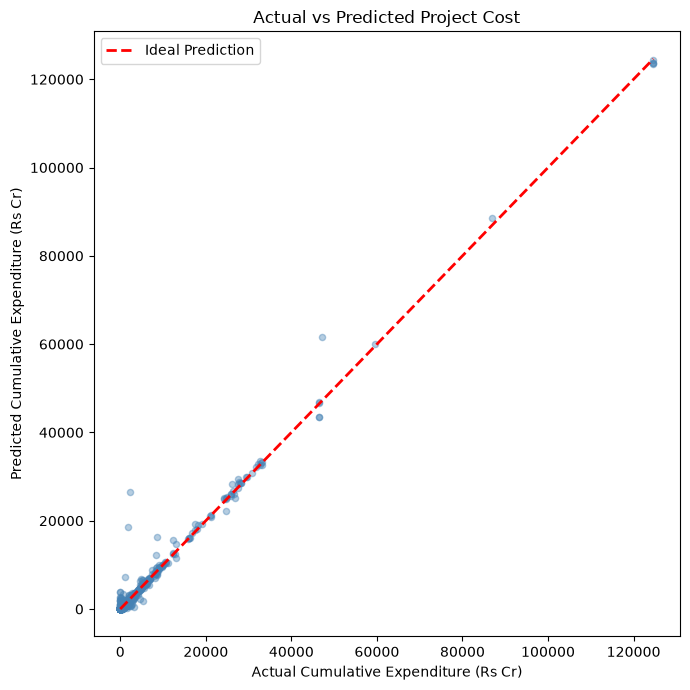

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_predictions, alpha=0.4, s=20, color="steelblue")
min_val = min(y_test.min(), best_predictions.min())
max_val = max(y_test.max(), best_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal Prediction")
plt.xlabel("Actual Cumulative Expenditure (Rs Cr)")
plt.ylabel("Predicted Cumulative Expenditure (Rs Cr)")
plt.title("Actual vs Predicted Project Cost")
plt.legend()
plt.tight_layout()
plt.show()


## Cell 15 — Residual Analysis

Residuals (`actual - predicted`) for the best model, with their mean and standard
deviation — a mean near zero and no strong skew indicates a well-calibrated model.


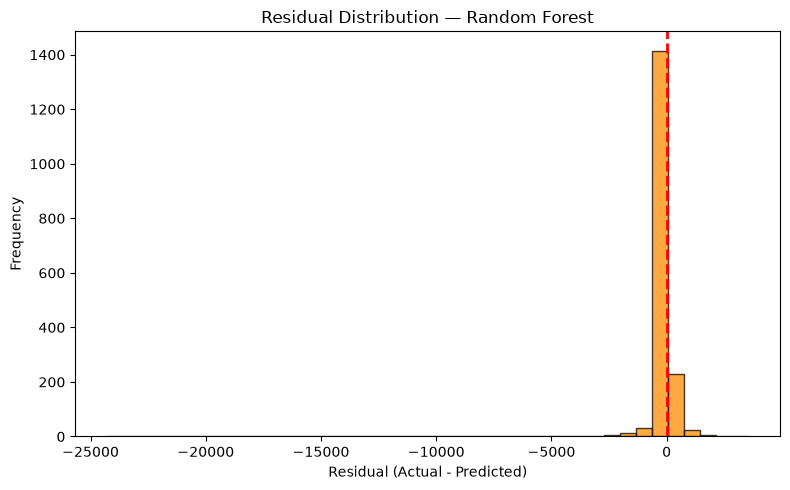

Mean Residual: -73.96
Standard Deviation of Residuals: 911.99


In [15]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, color="darkorange", edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution — {best_name}")
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():,.2f}")
print(f"Standard Deviation of Residuals: {residuals.std():,.2f}")


## Cell 16 — Feature Importance (Best Model)

Transformed feature names are recovered from the fitted `ColumnTransformer` (numeric
features pass through unchanged; categorical features are expanded by the
`OneHotEncoder`), then matched against `feature_importances_` from the best model's
regressor — this works identically for Random Forest and XGBoost since both expose
`feature_importances_`.


In [16]:
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

feature_names = list(numeric_features)
if categorical_features:
    ohe = fitted_preprocessor.named_transformers_["cat"].named_steps["onehot"]
    feature_names += list(ohe.get_feature_names_out(categorical_features))

importances = best_pipeline.named_steps["regressor"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names, "importance": importances
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1], color="seagreen")
plt.xlabel("Importance")
plt.title("Top 15 Features Influencing Project Cost Prediction")
plt.tight_layout()
plt.show()

display(importance_df)


ValueError: All arrays must be of the same length

## Cell 17 — Prediction Examples

20 random test-set rows: actual cost, predicted cost, and absolute error (best model).


In [ ]:
examples_df = pd.DataFrame({
    "Actual Cost (Rs Cr)": y_test.values,
    "Predicted Cost (Rs Cr)": best_predictions,
})
examples_df["Absolute Error (Rs Cr)"] = (
    examples_df["Actual Cost (Rs Cr)"] - examples_df["Predicted Cost (Rs Cr)"]
).abs()
examples_df = examples_df.round(2)

sample_size = min(20, len(examples_df))
display(examples_df.sample(n=sample_size, random_state=RANDOM_STATE).reset_index(drop=True))


Number of transformed features: 346
Number of importances: 346


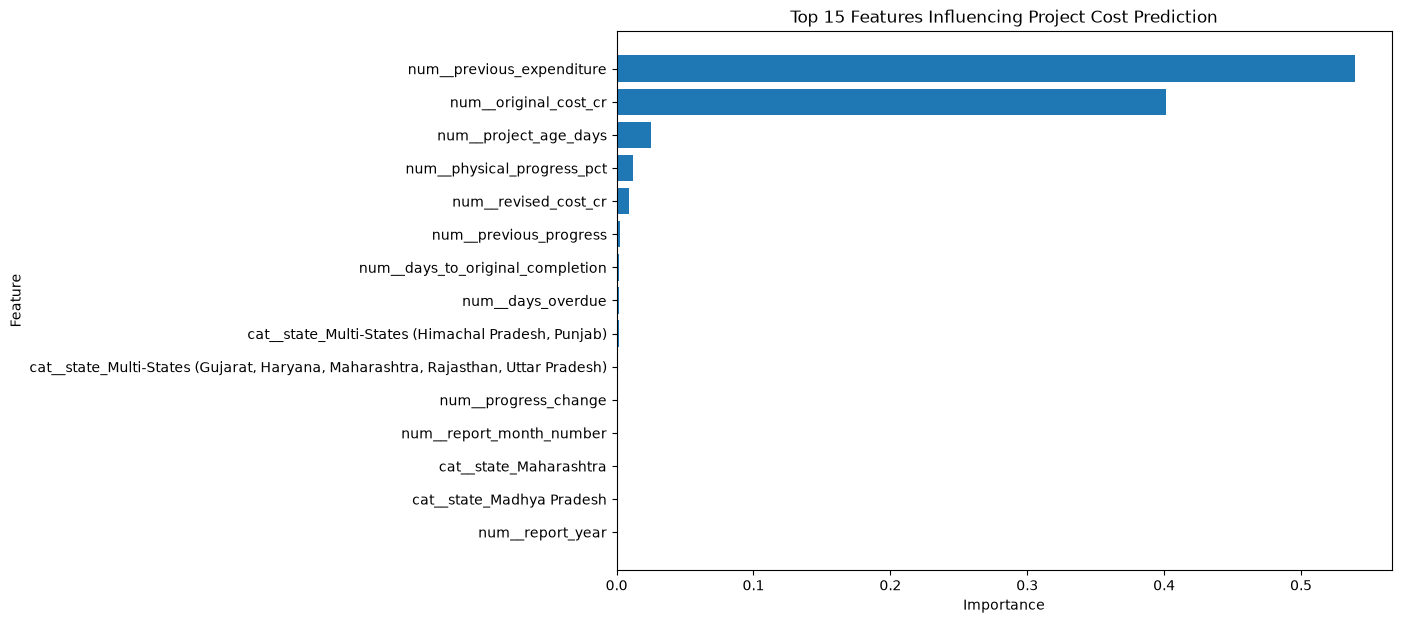

,feature,importance
4,num__previous_expenditure,0.539198
0,num__original_cost_cr,0.401493
6,num__project_age_days,0.025415
2,num__physical_progress_pct,0.012282
1,num__revised_cost_cr,0.009135
3,num__previous_progress,0.002264
7,num__days_to_original_completion,0.001763
8,num__days_overdue,0.001511
296,"cat__state_Multi-States (Himachal Pradesh, Pun...",0.001391
284,"cat__state_Multi-States (Gujarat, Haryana, Mah...",0.001242


In [17]:
# ============================================================
# FEATURE IMPORTANCE — RANDOM FOREST
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Get the fitted preprocessor
fitted_preprocessor = best_pipeline.named_steps["preprocessor"]

# Get the ACTUAL feature names after preprocessing
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Random Forest feature importances
importances = best_pipeline.named_steps["regressor"].feature_importances_

# Safety check
print("Number of transformed features:", len(feature_names))
print("Number of importances:", len(importances))

# Create DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort and get top 15
importance_df = (
    importance_df
    .sort_values("importance", ascending=False)
    .head(15)
)

# Plot
plt.figure(figsize=(10, 7))
plt.barh(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Influencing Project Cost Prediction")

plt.show()

# Display table
display(importance_df)

## Cell 19 — Multiple Scenario Demonstration

Three hypothetical projects — low-cost/early-stage, medium-cost/mid-progress, and a
large high-cost project — each built with `build_input_row` and predicted by the same
trained best model, to show judges how the prediction responds to changing inputs.


In [21]:
# ============================================================
# HELPER FUNCTION — BUILD COMPLETE MODEL INPUT
# ============================================================

def build_input_row(overrides):
    
    # Start with typical/default values from training data
    input_data = {}
    
    for feature in selected_features:
        
        # If the feature is numeric, use median
        if feature in numeric_features:
            input_data[feature] = X[feature].median()
        
        # If the feature is categorical, use most common value
        elif feature in categorical_features:
            input_data[feature] = X[feature].mode()[0]
    
    # Replace default values with scenario values
    input_data.update(overrides)
    
    # Create a DataFrame with exactly the required columns
    input_df = pd.DataFrame(
        [input_data],
        columns=selected_features
    )
    
    return input_df

In [22]:
# Get valid agency and state values from the training data
example_agency = X["agency"].dropna().iloc[0]
example_state = X["state"].dropna().iloc[0]

scenarios = {
    "Scenario 1: Low cost, early stage": {
        "project_age_days": 150,
        "physical_progress_pct": 10,
        "original_cost_cr": 50,
        "revised_cost_cr": 50,
        "previous_expenditure": 5,
    },

    "Scenario 2: Medium cost, mid progress": {
        "project_age_days": 800,
        "physical_progress_pct": 65,
        "original_cost_cr": 300,
        "revised_cost_cr": 340,
        "previous_expenditure": 180,
    },

    "Scenario 3: Large infrastructure, high revised cost": {
        "project_age_days": 2800,
        "physical_progress_pct": 85,
        "original_cost_cr": 2000,
        "revised_cost_cr": 2800,
        "previous_expenditure": 2100,
    }
}


scenario_rows = []

for label, overrides in scenarios.items():

    # Keep only features used by the model
    valid_overrides = {
        k: v for k, v in overrides.items()
        if k in selected_features
    }

    # Add categorical features if required
    if "agency" in selected_features:
        valid_overrides["agency"] = example_agency

    if "state" in selected_features:
        valid_overrides["state"] = example_state

    # Build complete input row
    input_df = build_input_row(valid_overrides)

    # Make prediction
    prediction = best_pipeline.predict(input_df)[0]

    # Store results
    scenario_rows.append({
        "Scenario": label,
        "Project Age": overrides.get("project_age_days"),
        "Physical Progress (%)": overrides.get("physical_progress_pct"),
        "Original Cost (Rs Cr)": overrides.get("original_cost_cr"),
        "Revised Cost (Rs Cr)": overrides.get("revised_cost_cr"),
        "Predicted Cumulative Expenditure (Rs Cr)": round(float(prediction), 2)
    })


scenario_df = pd.DataFrame(scenario_rows)

display(scenario_df)

,Scenario,Project Age,Physical Progress (%),Original Cost (Rs Cr),Revised Cost (Rs Cr),Predicted Cumulative Expenditure (Rs Cr)
0,"Scenario 1: Low cost, early stage",150,10,50,50,8.52
1,"Scenario 2: Medium cost, mid progress",800,65,300,340,198.35
2,"Scenario 3: Large infrastructure, high revised...",2800,85,2000,2800,2101.41


## Cell 20 — Save the Best Model

The full best-model pipeline (preprocessing + regressor) is saved with `joblib`, along
with a `model_metadata.json` describing what was selected and how it performed.


In [23]:
MODEL_PATH = "best_project_cost_prediction_model.pkl"
METADATA_PATH = "model_metadata.json"

joblib.dump(best_pipeline, MODEL_PATH)

metadata = {
    "best_model_name": best_name,
    "MAE": float(best_info["MAE"]),
    "RMSE": float(best_info["RMSE"]),
    "R2_score": float(best_info["R2"]),
    "target_column": TARGET,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
}
with open(METADATA_PATH, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Best model pipeline saved to: {MODEL_PATH}")
print(f"Metadata saved to: {METADATA_PATH}")
print("\nMetadata contents:")
print(json.dumps(metadata, indent=2))


Best model pipeline saved to: best_project_cost_prediction_model.pkl
Metadata saved to: model_metadata.json

Metadata contents:
{
  "best_model_name": "Random Forest",
  "MAE": 184.77141358644684,
  "RMSE": 914.7222276284261,
  "R2_score": 0.987070242624087,
  "target_column": "cumulative_expenditure_cr",
  "numeric_features": [
    "original_cost_cr",
    "revised_cost_cr",
    "physical_progress_pct",
    "previous_progress",
    "previous_expenditure",
    "progress_change",
    "project_age_days",
    "days_to_original_completion",
    "days_overdue",
    "report_year",
    "report_month_number",
    "project_start_year"
  ],
  "categorical_features": [
    "agency",
    "state"
  ]
}


## Cell 21 — Final Model Summary


In [24]:
print("=" * 52)
print("PROJECT COST PREDICTION MODEL - FINAL RESULTS")
print("=" * 52)
print(f"\nDataset Used:\n  {DATA_PATH}")
print(f"\nTotal Original Rows:\n  {ORIGINAL_ROW_COUNT}")
print(f"\nRows Used for Training+Testing (valid target):\n  {len(df)}")
print(f"\nTraining Samples:\n  {X_train.shape[0]}")
print(f"Testing Samples:\n  {X_test.shape[0]}")
print(f"\nTarget:\n  {TARGET}")
print("\nModels Compared:\n  1. Dummy Baseline\n  2. Random Forest Regressor"
      + ("\n  3. XGBoost Regressor" if xgb_pipeline is not None else "\n  (XGBoost not installed - not compared)"))
print(f"\nBEST MODEL:\n  {best_name}")
print("\nFINAL PERFORMANCE:")
print(f"  MAE:      Rs {best_info['MAE']:,.2f} Cr")
print(f"  RMSE:     Rs {best_info['RMSE']:,.2f} Cr")
print(f"  R2 Score: {best_info['R2']:.4f}")
print(f"\nInterpretation:\n  An R2 score of {best_info['R2']:.4f} means the model explains "
      f"about {best_info['R2']*100:.1f}% of the variation in cumulative project "
      f"expenditure using the selected features. The remaining variation is due to "
      f"factors not captured in this dataset or inherent project-level unpredictability.")
print("\nThis model predicts expected cumulative project expenditure using project "
      "cost, progress, historical expenditure, time-related, agency, and state-level "
      "information.")
print("=" * 52)


PROJECT COST PREDICTION MODEL - FINAL RESULTS

Dataset Used:
  paimana_features.csv

Total Original Rows:
  9676

Rows Used for Training+Testing (valid target):
  8676

Training Samples:
  6940
Testing Samples:
  1736

Target:
  cumulative_expenditure_cr

Models Compared:
  1. Dummy Baseline
  2. Random Forest Regressor
  3. XGBoost Regressor

BEST MODEL:
  Random Forest

FINAL PERFORMANCE:
  MAE:      Rs 184.77 Cr
  RMSE:     Rs 914.72 Cr
  R2 Score: 0.9871

Interpretation:
  An R2 score of 0.9871 means the model explains about 98.7% of the variation in cumulative project expenditure using the selected features. The remaining variation is due to factors not captured in this dataset or inherent project-level unpredictability.

This model predicts expected cumulative project expenditure using project cost, progress, historical expenditure, time-related, agency, and state-level information.
